### Importing Libraries

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import time
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,  classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier

from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
import statsmodels.api as sm


from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, DotProduct, ConstantKernel as C, WhiteKernel
from sklearn.svm import SVC


### Data Exploration

In [2]:
df = pd.read_csv("online_course_engagement_data.csv")

In [3]:
print("Shape:", df.shape)
df.head()

Shape: (9000, 9)


,UserID,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
0,5618,Health,29.979719,17,3,50.365656,20.860773,1,0
1,4326,Arts,27.802640,1,5,62.615970,65.632415,1,0
2,5849,Arts,86.820485,14,2,78.458962,63.812007,1,1
3,4992,Science,35.038427,17,10,59.198853,95.433162,0,1
4,3866,Programming,92.490647,16,0,98.428285,18.102478,0,0


#### There are 9000 rows and 9 columns originally but after removing the duplicates, the dataframe has 8,123 rows and 9 columns.

In [4]:
df = df.drop_duplicates()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8123 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UserID                 8123 non-null   int64  
 1   CourseCategory         8123 non-null   object 
 2   TimeSpentOnCourse      8123 non-null   float64
 3   NumberOfVideosWatched  8123 non-null   int64  
 4   NumberOfQuizzesTaken   8123 non-null   int64  
 5   QuizScores             8123 non-null   float64
 6   CompletionRate         8123 non-null   float64
 7   DeviceType             8123 non-null   int64  
 8   CourseCompletion       8123 non-null   int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 634.6+ KB


In [6]:
df["CourseCategory"].value_counts(normalize= True)

CourseCategory
Business       0.203989
Health         0.201157
Programming    0.201034
Science        0.200542
Arts           0.193278
Name: proportion, dtype: float64

#### No null values in any column as shown by the dataFrame information function
#### There is only one categorical column: CourseCategory
- The categories are Business, Health, Science, Programming, Arts

#### While all the other 8 columns are Numerical variables

### Data Visualization

### Target Columns Distribution

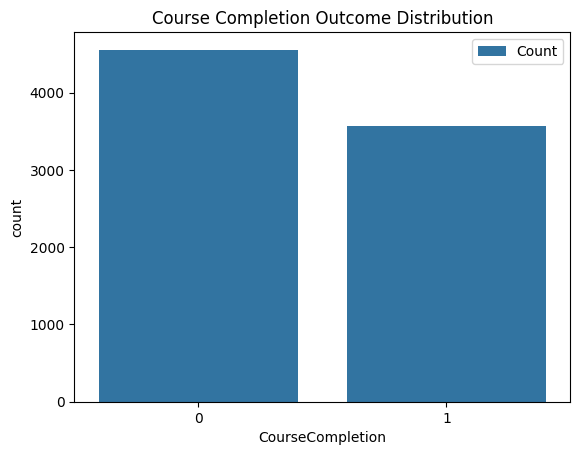

There are a total of 8123 observations in this dataset
The number of True outcomes is 3568 which is 43.92 percent of the total observations
The number of False outcomes is 4555 which is 56.1 percent of the total observations


In [7]:

## Check for target variable distribution

sns.countplot(x = df['CourseCompletion'],label="Count")
plt.title('Course Completion Outcome Distribution')
plt.show()

print("There are a total of %s observations in this dataset" %(len(df)))
print("The number of True outcomes is %s which is %.2f percent of the total observations"
      %(len(df.loc[df['CourseCompletion']==1]),(len(df.loc[df['CourseCompletion']==1]) / len(df)) * 100))
print("The number of False outcomes is %s which is %.1f percent of the total observations"
      %(len(df.loc[df['CourseCompletion']==0]),(len(df.loc[df['CourseCompletion']==0]) / len(df)) * 100))


### Categorical Columns Distribution

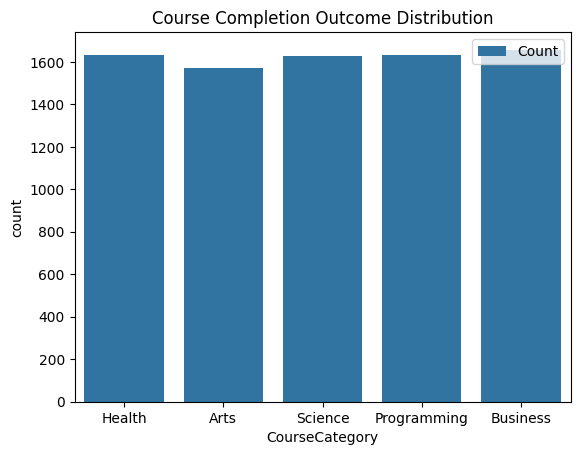

There are a total of 8123 observations in this dataset

The percentage distribution for each are as follows: CourseCategory
Business       20.398867
Health         20.115721
Programming    20.103410
Science        20.054167
Arts           19.327835
Name: proportion, dtype: float64


In [8]:
## Check for target variable distribution

sns.countplot(x = df['CourseCategory'],label="Count")
plt.title('Course Completion Outcome Distribution')
plt.show()

print("There are a total of %s observations in this dataset" %(len(df)))
print()
print("The percentage distribution for each are as follows:", df["CourseCategory"].value_counts(normalize = True)*100)

### Numerical Columns Distribution

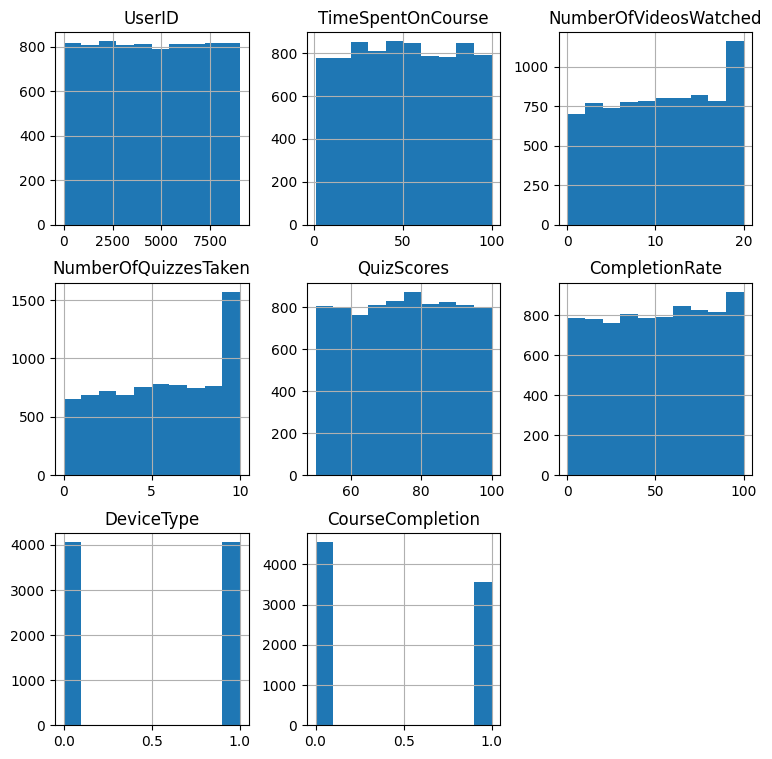

In [9]:
df.hist(bins=10, figsize=(9, 9))  # Generate histograms for all numeric columns
plt.show()

In [10]:
df.describe()

,UserID,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
count,8123.000000,8123.000000,8123.000000,8123.000000,8123.000000,8123.000000,8123.000000,8123.000000
mean,4504.687185,50.607728,10.148098,5.166933,75.091084,51.190873,0.500431,0.439247
std,2604.220672,28.364184,5.987972,3.132108,14.339876,29.069716,0.500031,0.496326
min,1.000000,1.005230,0.000000,0.000000,50.005119,0.009327,0.000000,0.000000
25%,2248.500000,26.114631,5.000000,2.000000,62.791226,26.276765,0.000000,0.000000
50%,4492.000000,50.316921,10.000000,5.000000,75.273913,51.581186,1.000000,0.000000
75%,6766.500000,75.377730,15.000000,8.000000,87.497542,76.729629,1.000000,1.000000
max,9000.000000,99.992558,20.000000,10.000000,99.994984,99.979711,1.000000,1.000000


Most of the numerical columns look distributed with no strong skew, so transformations are not needed.

- **TimeSpentOnCourse** looks uniform across its range

- **NumberOfVideosWatched** is spread fairly evenly

- **NumberOfQuizzesTaken** is discrete but balanced

- **QuizScores** looks a bit symmetric

- **CompletionRate** is also evenly distributed from 0–100

For the remaining columns:

- **UserID** is just an identifier, so it should be dropped rather than transformed

- **DeviceType** is binary (0/1), so no transformation is needed

- **CourseCompletion** is also binary (target variable), so it does not require transformation

### Removing columns that are not significant in the analysis because values are constant for almost everyone.

In [11]:
drop_cols = ["UserID"]

df = df.drop(columns=drop_cols, errors="ignore")
df.shape

(8123, 8)

In [12]:
df.columns

Index(['CourseCategory', 'TimeSpentOnCourse', 'NumberOfVideosWatched',
       'NumberOfQuizzesTaken', 'QuizScores', 'CompletionRate', 'DeviceType',
       'CourseCompletion'],
      dtype='object')

### Bivariate relationships

#### Boxplots 
- very obvious chatgpt code (from the tutorial, not saying anything)

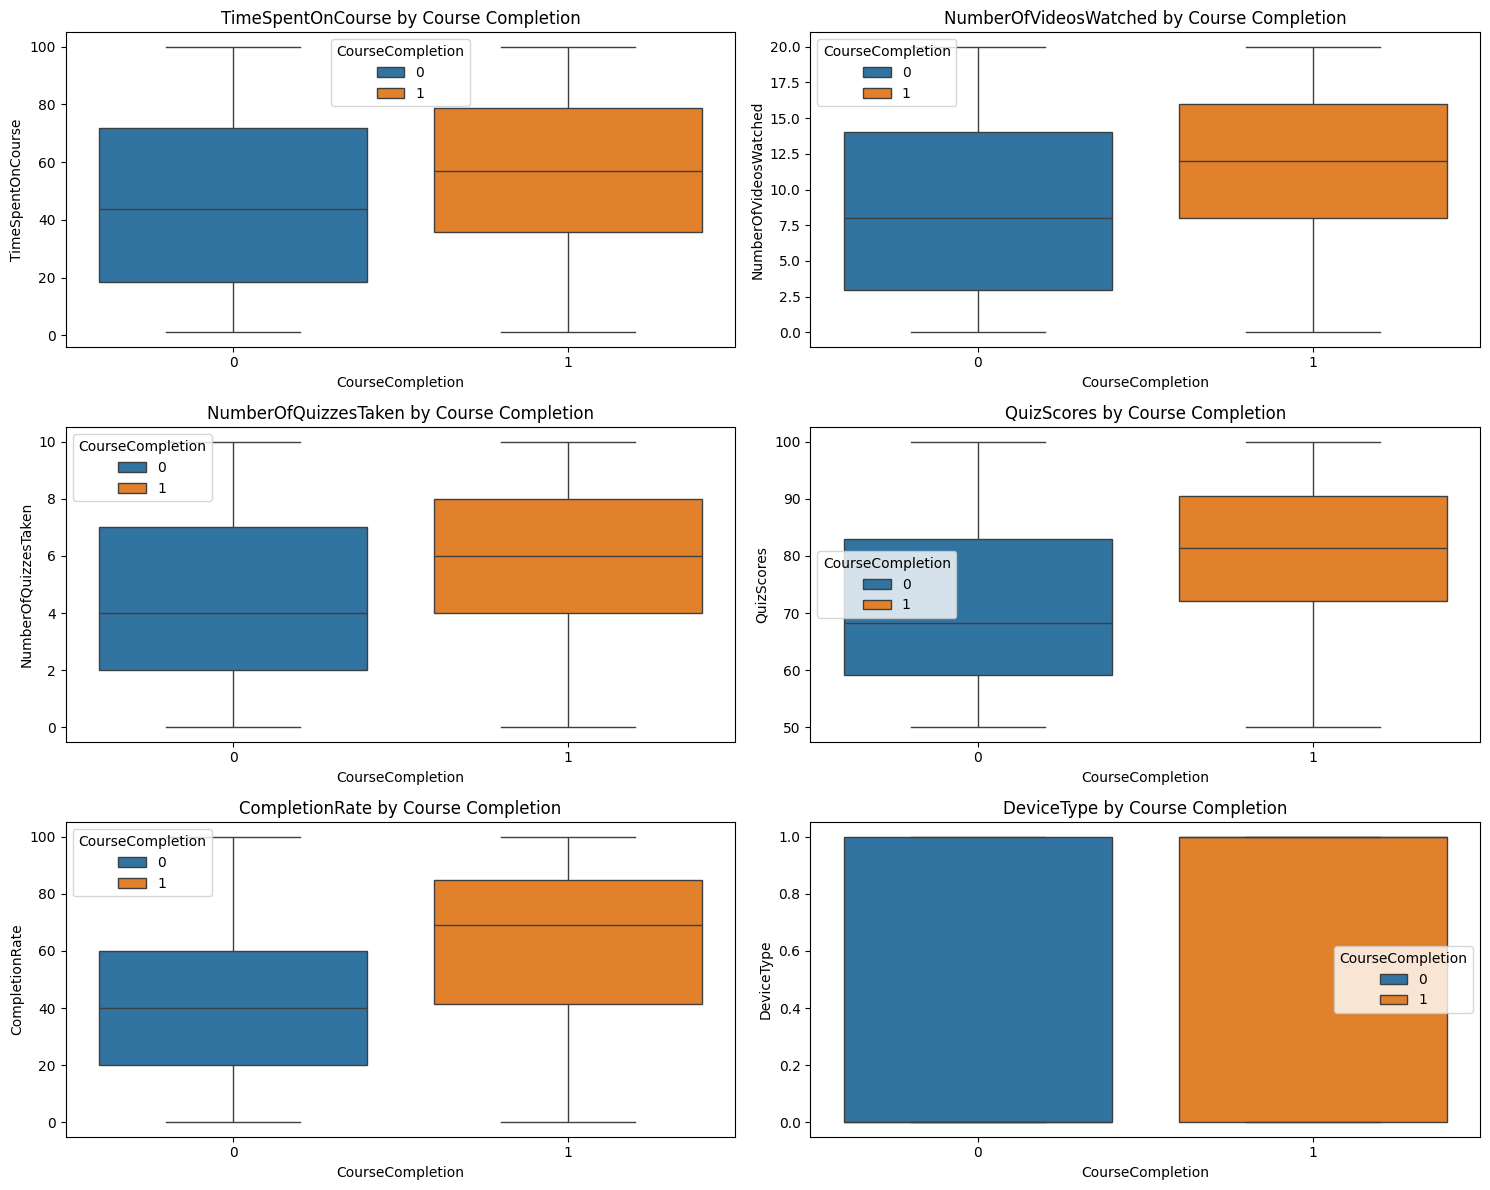

In [13]:
# Box Plots for All Variables vs. Target Variable

# Select numeric columns excluding the target and other specified variables
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
numeric_columns = [col for col in numeric_columns if col not in ['CourseCompletion', 'CourseCategory']]  # Exclude specified columns

# Set up the grid dimensions
n_cols = 2  # Number of plots per row
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols  # Calculate rows dynamically

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))  # Adjust size as needed
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Loop through each numeric column and plot
for i, column in enumerate(numeric_columns):
    sns.boxplot(ax=axes[i], x="CourseCompletion", y=column, data=df, hue="CourseCompletion", dodge=False)
    axes[i].set_title(f"{column} by Course Completion")
    axes[i].set_xlabel("CourseCompletion")
    axes[i].set_ylabel(column)

# Hide any unused subplots
for i in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[i])  # Remove unused axes

# Adjust layout
plt.tight_layout()
plt.show()

#### Explanation:

* **TimeSpentOnCourse:** Students who completed the course spent more time on it than those who did not.

* **NumberOfVideosWatched:** Completers tend to watch more course videos.

* **NumberOfQuizzesTaken:** Students who finished the course usually took more quizzes compared to non-completers.

* **QuizScores:** Higher quiz scores are seen among completers.

* **CompletionRate:** Completers have much higher completion rates than non-completers.

* **DeviceType:** No obvious difference between groups, so device type does not seem to be related to completion.



### Correlationship Matrix to identify patterns for later's bivariate relationships

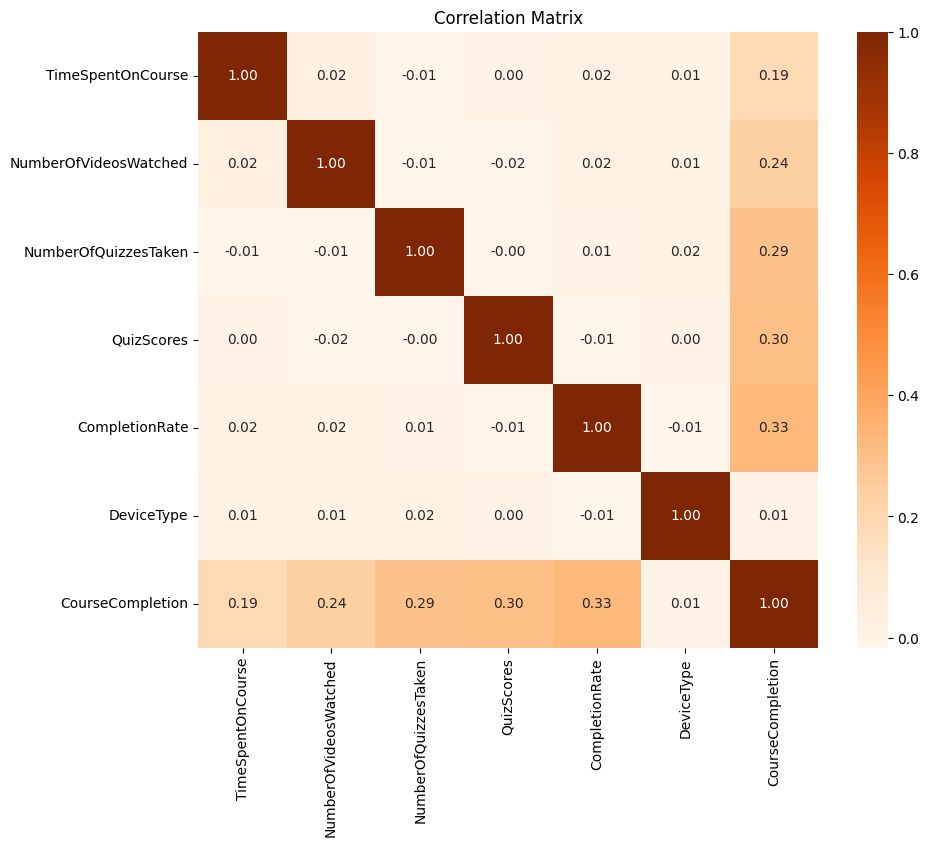

In [14]:
# Correlation matrix visualization
# Filter numerical columns only
numerical_data = df.select_dtypes(include=["number"])

# Correlation matrix visualization
plt.figure(figsize=(10, 8))  # Set the figure size
sns.heatmap(numerical_data.corr(), cmap="Oranges", annot=True, fmt=".2f", square=False)
plt.title("Correlation Matrix")
plt.show()


### Explanation:

Overall, the heatmap shows very low correlation between most of the variables, which is good because it means there is little multicollinearity for modeling. The highest correlations with course completion are CompletionRate (positive, moderate, r = 0.33), QuizScores (positive, moderate, r = 0.30), and NumberOfQuizzesTaken (positive, weak–moderate, r = 0.28), but these are still only moderate.

### Preparing for Modelling

In [15]:
# create a copy of dataframe so that the changes don't affect the original data
df2 = df.copy()

In [16]:
df2.head()

,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
0,Health,29.979719,17,3,50.365656,20.860773,1,0
1,Arts,27.802640,1,5,62.615970,65.632415,1,0
2,Arts,86.820485,14,2,78.458962,63.812007,1,1
3,Science,35.038427,17,10,59.198853,95.433162,0,1
4,Programming,92.490647,16,0,98.428285,18.102478,0,0


### Before jumping to modeling, we should standardize our data

In [17]:
## Standardize the numeric features
SC = StandardScaler()  # Create an instance of StandardScaler, which standardizes data by removing the mean and scaling to unit variance

#Dropping Non-Numeric or Irrelevant Columns (Columns like Outcome, Social smoker, and Social drinker are excluded as they might be categorical or targets not meant for standardization.)
X_to_be_SC = df2.drop(['CourseCompletion', 'DeviceType', 'CourseCategory'], axis=1)  # delete binary features , axis=1 drop from columns

X_CS = SC.fit_transform(X_to_be_SC)  #fit_transform performs both fitting (computing mean and standard deviation) and transforming (applying scaling).
# Fit the StandardScaler to the data (computes the mean and standard deviation)
# and then transform the data to standardize it (z = (x - mean) / std_dev).
# The result is a NumPy array with the same shape as X_to_be_SC.

X_SC = pd.DataFrame(X_CS, columns=X_to_be_SC.columns)
# Convert the standardized NumPy array (X_CS) back into a pandas DataFrame.
# Use the original column names from X_to_be_SC for the new DataFrame to maintain clarity.

X_SC.head()
# Display the first five rows of the standardized DataFrame to verify the results.

,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate
0,-0.727300,1.144348,-0.691888,-1.724349,-1.043422
1,-0.804060,-1.527840,-0.053301,-0.870013,0.496820
2,1.276786,0.643313,-1.011181,0.234876,0.434194
3,-0.548941,1.144348,1.543166,-1.108323,1.522031
4,1.476704,0.977336,-1.649768,1.627534,-1.138313


#### Explanation:
    
Basically we standardized all the numerical columns in the code above but we did not include the binary columns ('DeviceType') because we should not and also the target column ('CourseCompletion'). So now, dataframe X_SC only contains the columns that we standardized (which you can see in the X_SC_head() code)

#### Adding dummies for the categorical column (CourseCategory)
rule: m-1 (# of columns minus 1 for the base)

In [18]:
course_dummies = pd.get_dummies(df2['CourseCategory'], prefix='CourseCategory', drop_first=True)

In [19]:
course_dummies.head()

,CourseCategory_Business,CourseCategory_Health,CourseCategory_Programming,CourseCategory_Science
0,False,True,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,True
4,False,False,True,False


### Clean overall dataframe ready for modeling

In [20]:
df_clean = pd.concat([X_SC,df2[['DeviceType', 'CourseCompletion']].reset_index(drop=True),
        course_dummies.reset_index(drop=True)],axis=1)

df_clean.head()

,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion,CourseCategory_Business,CourseCategory_Health,CourseCategory_Programming,CourseCategory_Science
0,-0.727300,1.144348,-0.691888,-1.724349,-1.043422,1,0,False,True,False,False
1,-0.804060,-1.527840,-0.053301,-0.870013,0.496820,1,0,False,False,False,False
2,1.276786,0.643313,-1.011181,0.234876,0.434194,1,1,False,False,False,False
3,-0.548941,1.144348,1.543166,-1.108323,1.522031,0,1,False,False,False,True
4,1.476704,0.977336,-1.649768,1.627534,-1.138313,0,0,False,False,True,False


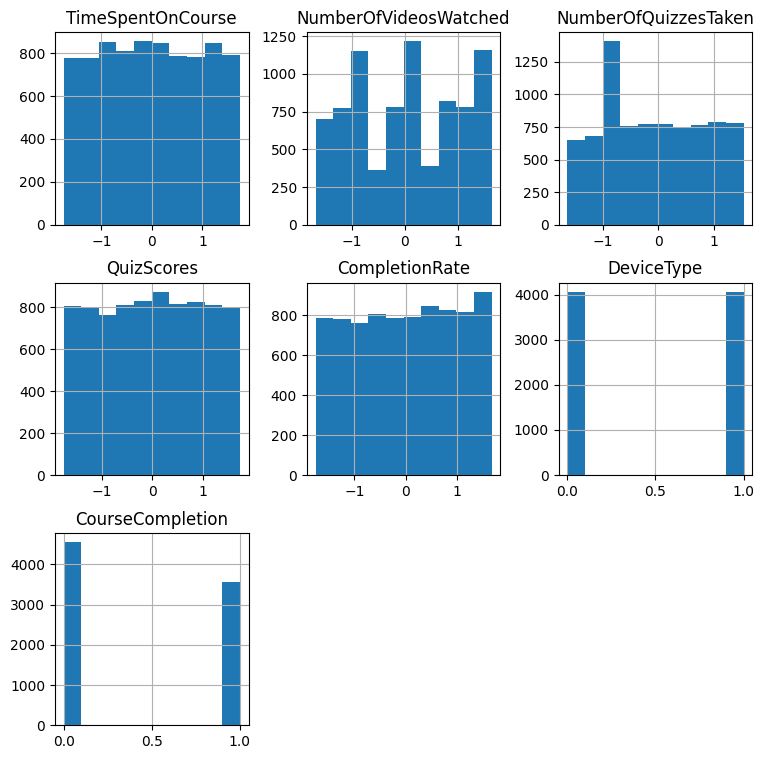

In [21]:
df_clean.hist(bins=10, figsize=(9, 9))  # Generate histograms for all numeric columns
plt.show()

#### the range is now -1 to 1

In [22]:
# df_clean.to_csv("df_model.csv")

#### Explanation:

We created a new dataframe (df_clean) that contains scaled numerical features, the binary predictor, and the dummy variables ready for modeling.

#### Specifying the the independent and dependent variables

In [23]:
## Specify the feature and target datasets [X and y]
# Combine standardized features with binary columns

X= df_clean.drop(columns=['CourseCompletion']) # all columns but not the target
y = df_clean['CourseCompletion'].reset_index(drop=True)  # Reset index for consistency

# Check for consistent lengths
print(f"Length of X: {len(X)}")
print(f"Length of y: {len(y)}")

Length of X: 8123
Length of y: 8123


In [24]:
X.head()

,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCategory_Business,CourseCategory_Health,CourseCategory_Programming,CourseCategory_Science
0,-0.727300,1.144348,-0.691888,-1.724349,-1.043422,1,False,True,False,False
1,-0.804060,-1.527840,-0.053301,-0.870013,0.496820,1,False,False,False,False
2,1.276786,0.643313,-1.011181,0.234876,0.434194,1,False,False,False,False
3,-0.548941,1.144348,1.543166,-1.108323,1.522031,0,False,False,False,True
4,1.476704,0.977336,-1.649768,1.627534,-1.138313,0,False,False,True,False


#### Explanation:

After standardizing the continuous features, we added back the binary predictor (DeviceType) to the feature set while keeping the target variable separate. We also converted the CourseCategory column into dummy variables and included them in the dataset. The resulting dataframe X now contains the scaled numerical features, the binary predictor, and the dummy variables, as shown in X.head().

### We ready for modelling

In [25]:
# 1) Make sure X and y are pandas objects
X = X.copy()
y = pd.Series(y).copy()

# 2) Convert booleans -> 0/1
bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

# 3) Force everything to numeric (any weird values become NaN)
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# 4) Drop rows with NaNs and align X/y
df = pd.concat([X, y.rename("y")], axis=1).dropna()
X_clean = df.drop(columns=["y"])
y_clean = df["y"]

# 5) Add intercept + fit OLS
X_clean = sm.add_constant(X_clean, has_constant="add")
model = sm.OLS(y_clean, X_clean).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     489.3
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:40:32   Log-Likelihood:                -3918.3
No. Observations:                8123   AIC:                             7859.
Df Residuals:                    8112   BIC:                             7936.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

#### Splitting data for training and testing

In [26]:
# Step 1: Split the dataset into training (80%) and test sets (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

# Step 2: Print the shapes of the partitions
print(f"Shape of partitions:")
print(f" X_train: {X_train.shape}")
print(f" X_test: {X_test.shape}")

# Calculate and display the sizes as percentages
total_samples = len(X)  # Assuming X and y have the same number of rows
print(f"The size of the Training set is: {len(X_train)} ({len(X_train)/total_samples*100:.2f}%)")
print(f"The size of the Test set is: {len(X_test)} ({len(X_test)/total_samples*100:.2f}%)")

Shape of partitions:
 X_train: (6498, 10)
 X_test: (1625, 10)
The size of the Training set is: 6498 (80.00%)
The size of the Test set is: 1625 (20.00%)


In [27]:
X_train.head()

,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCategory_Business,CourseCategory_Health,CourseCategory_Programming,CourseCategory_Science
3635,-1.170062,-0.191746,-1.649768,1.310579,1.054050,0,0,0,0,0
4165,0.848713,0.643313,1.223873,1.236213,-0.545471,0,0,0,1,0
1331,0.412301,0.476301,-0.372594,1.719008,1.339001,1,0,0,0,1
7858,0.582679,1.144348,-0.691888,0.345503,0.455009,0,0,1,0,0
137,-1.724779,-0.859793,0.904580,0.797124,-1.133234,1,0,0,1,0


### Model 1: Naives Bayes

In [28]:
cv = StratifiedKFold(n_splits=10,shuffle=True,random_state=32)

In [31]:
start_time = time.time()

# 1) Define model
gnb = GaussianNB()

# 2) 10-fold cross-validation (CV) on TRAINING set
cv_scores = cross_validate(
    gnb,
    X_train, y_train,
    cv=cv,  # your StratifiedKFold(n_splits=10, shuffle=True, random_state=32)
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=False)

# 3) Compute mean and std for CV metrics
cv_results = {
    "Accuracy (CV)": (cv_scores["test_accuracy"].mean(), cv_scores["test_accuracy"].std()),
    "Precision (CV)": (cv_scores["test_precision"].mean(), cv_scores["test_precision"].std()),
    "Recall (CV)": (cv_scores["test_recall"].mean(), cv_scores["test_recall"].std()),
    "F1 (CV)": (cv_scores["test_f1"].mean(), cv_scores["test_f1"].std()),}

print("=== 10-Fold CV Results (Train Set) ===")
for metric, (mean_val, std_val) in cv_results.items():
    print(f"{metric}: mean={mean_val:.4f}, std={std_val:.4f}")

# 4) Fit on full training set
gnb.fit(X_train, y_train)

# 5) Predict on test set
y_pred = gnb.predict(X_test)

# 6) Test accuracy
test_acc = accuracy_score(y_test, y_pred)
print("\n=== Test Set Results ===")
print(f"Test Accuracy: {test_acc:.4f}")

# 7) Confusion Matrix (TN, FP, FN, TP)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# 8) End timer
end_time = time.time()
runtime = end_time - start_time

print(f"\nRuntime (seconds): {runtime:.4f}")


=== 10-Fold CV Results (Train Set) ===
Accuracy (CV): mean=0.8263, std=0.0144
Precision (CV): mean=0.8327, std=0.0221
Recall (CV): mean=0.7580, std=0.0249
F1 (CV): mean=0.7933, std=0.0178

=== Test Set Results ===
Test Accuracy: 0.8160

Confusion Matrix:
[[782 134]
 [165 544]]
TN=782, FP=134, FN=165, TP=544

Runtime (seconds): 0.1885


### Model 2: Naive Bayes (without Device Type)

In [32]:
X_train_no_device = X_train.drop(columns=["DeviceType"]).copy()
X_test_no_device  = X_test.drop(columns=["DeviceType"]).copy()

In [33]:
start_time = time.time()

# 1) Define model again
gnb = GaussianNB()

# 2) 10-fold cross-validation on TRAINING set (without DeviceType)
cv_scores = cross_validate(
    gnb,
    X_train_no_device, y_train,
    cv=cv,  # your StratifiedKFold(n_splits=10, shuffle=True, random_state=32)
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=False)

print("=== 10-Fold CV Results (Train Set) - WITHOUT DeviceType ===")
print(f"Accuracy (CV):   mean={cv_scores['test_accuracy'].mean():.4f}, std={cv_scores['test_accuracy'].std():.4f}")
print(f"Precision (CV):  mean={cv_scores['test_precision'].mean():.4f}, std={cv_scores['test_precision'].std():.4f}")
print(f"Recall (CV):     mean={cv_scores['test_recall'].mean():.4f}, std={cv_scores['test_recall'].std():.4f}")
print(f"F1 (CV):         mean={cv_scores['test_f1'].mean():.4f}, std={cv_scores['test_f1'].std():.4f}")

# 3) Fit on full training set
gnb.fit(X_train_no_device, y_train)

# 4) Predict on test set
y_pred = gnb.predict(X_test_no_device)

# 5) Test accuracy
test_acc = accuracy_score(y_test, y_pred)
print("\n=== Test Set Results - WITHOUT DeviceType ===")
print(f"Test Accuracy: {test_acc:.4f}")

# 6) Confusion Matrix (TN, FP, FN, TP)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# 7) End timer
runtime = time.time() - start_time
print(f"\nRuntime (seconds): {runtime:.4f}")

=== 10-Fold CV Results (Train Set) - WITHOUT DeviceType ===
Accuracy (CV):   mean=0.8253, std=0.0146
Precision (CV):  mean=0.8319, std=0.0232
Recall (CV):     mean=0.7566, std=0.0256
F1 (CV):         mean=0.7921, std=0.0180

=== Test Set Results - WITHOUT DeviceType ===
Test Accuracy: 0.8191

Confusion Matrix:
[[787 129]
 [165 544]]
TN=787, FP=129, FN=165, TP=544

Runtime (seconds): 0.2176


### Model 3: Naive Bayes (without Device Type and CourseCategory)

In [34]:
cols_to_remove = ["DeviceType"] + [col for col in X_train.columns if col.startswith("CourseCategory_")]

In [35]:
X_train_reduced = X_train.drop(columns=cols_to_remove).copy()
X_test_reduced  = X_test.drop(columns=cols_to_remove).copy()

In [36]:
start_time = time.time()

# 1) Define model again
gnb = GaussianNB()

# 2) 10-fold CV on TRAINING set
cv_scores = cross_validate(
    gnb,
    X_train_reduced, y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=False)

print("=== 10-Fold CV Results (WITHOUT DeviceType & CourseCategory) ===")
print(f"Accuracy (CV):   mean={cv_scores['test_accuracy'].mean():.4f}, std={cv_scores['test_accuracy'].std():.4f}")
print(f"Precision (CV):  mean={cv_scores['test_precision'].mean():.4f}, std={cv_scores['test_precision'].std():.4f}")
print(f"Recall (CV):     mean={cv_scores['test_recall'].mean():.4f}, std={cv_scores['test_recall'].std():.4f}")
print(f"F1 (CV):         mean={cv_scores['test_f1'].mean():.4f}, std={cv_scores['test_f1'].std():.4f}")

# 3) Fit full training set
gnb.fit(X_train_reduced, y_train)

# 4) Predict test set
y_pred = gnb.predict(X_test_reduced)

# 5) Test accuracy
test_acc = accuracy_score(y_test, y_pred)
print("\n=== Test Set Results (WITHOUT DeviceType & CourseCategory) ===")
print(f"Test Accuracy: {test_acc:.4f}")

# 6) Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# 7) Runtime
runtime = time.time() - start_time
print(f"\nRuntime (seconds): {runtime:.4f}")

=== 10-Fold CV Results (WITHOUT DeviceType & CourseCategory) ===
Accuracy (CV):   mean=0.8275, std=0.0152
Precision (CV):  mean=0.8351, std=0.0244
Recall (CV):     mean=0.7583, std=0.0232
F1 (CV):         mean=0.7945, std=0.0180

=== Test Set Results (WITHOUT DeviceType & CourseCategory) ===
Test Accuracy: 0.8160

Confusion Matrix:
[[785 131]
 [168 541]]
TN=785, FP=131, FN=168, TP=541

Runtime (seconds): 0.2092


### Model 4: Logistic Regression (Base model)

In [37]:
start_time = time.time()

# 1) Build pipeline: scaling happens INSIDE each CV fold
logreg_pipe = Pipeline(steps=[
    ("logreg", LogisticRegression(max_iter=1000, solver="lbfgs"))])

# 2) 10-fold cross-validation on TRAINING set
cv_scores = cross_validate(
    logreg_pipe,
    X_train, y_train,
    cv=cv,  # your StratifiedKFold(n_splits=10, shuffle=True, random_state=32)
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=False)

print("=== 10-Fold CV Results (Train Set) - Logistic Regression (Pipeline Scaled) ===")
print(f"Accuracy (CV):   mean={cv_scores['test_accuracy'].mean():.4f}, std={cv_scores['test_accuracy'].std():.4f}")
print(f"Precision (CV):  mean={cv_scores['test_precision'].mean():.4f}, std={cv_scores['test_precision'].std():.4f}")
print(f"Recall (CV):     mean={cv_scores['test_recall'].mean():.4f}, std={cv_scores['test_recall'].std():.4f}")
print(f"F1 (CV):         mean={cv_scores['test_f1'].mean():.4f}, std={cv_scores['test_f1'].std():.4f}")

# 3) Fit on full training set
logreg_pipe.fit(X_train, y_train)

# 4) Predict on test set
y_pred = logreg_pipe.predict(X_test)

# 5) Test accuracy
test_acc = accuracy_score(y_test, y_pred)
print("\n=== Test Set Results - Logistic Regression ===")
print(f"Test Accuracy: {test_acc:.4f}")

# 6) Confusion matrix (TN, FP, FN, TP)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# 7) Runtime
runtime = time.time() - start_time
print(f"\nRuntime (seconds): {runtime:.4f}")

=== 10-Fold CV Results (Train Set) - Logistic Regression (Pipeline Scaled) ===
Accuracy (CV):   mean=0.7926, std=0.0143
Precision (CV):  mean=0.7736, std=0.0247
Recall (CV):     mean=0.7485, std=0.0190
F1 (CV):         mean=0.7605, std=0.0152

=== Test Set Results - Logistic Regression ===
Test Accuracy: 0.7822

Confusion Matrix:
[[729 187]
 [167 542]]
TN=729, FP=187, FN=167, TP=542

Runtime (seconds): 0.2569


### Model 5: Logistic Regression with HyperParam tuning

In [38]:
model = LogisticRegression(solver="liblinear",class_weight="balanced",max_iter=5000,random_state=32)

cv_method = StratifiedKFold(n_splits=10, shuffle=True, random_state=32)

# Metrics to evaluate
metrics = ["accuracy", "precision", "recall", "f1"]

cv_results = {}

# START TIMER
start = time.perf_counter()

# Run CV for each metric
for m in metrics:
    scores = cross_val_score(model, X_train, y_train, cv=cv_method, scoring=m)
    cv_results[m] = scores

# END TIMER
end = time.perf_counter()

In [39]:
for m in metrics:
    scores = cv_results[m]
    print(f"\nCV fold {m}:", scores)
    print(f"Mean CV {m}: {scores.mean():.4f}")
    print(f"Std CV {m}: {scores.std(ddof=1):.4f}")

print(f"\nCV runtime: {end-start:.4f} seconds")


CV fold accuracy: [0.78615385 0.77692308 0.75846154 0.79692308 0.79692308 0.82
 0.80153846 0.77692308 0.79352851 0.81510015]
Mean CV accuracy: 0.7922
Std CV accuracy: 0.0185

CV fold precision: [0.74915254 0.73898305 0.70219436 0.74367089 0.76013514 0.79442509
 0.7460815  0.73421927 0.74917492 0.76433121]
Mean CV precision: 0.7482
Std CV precision: 0.0235

CV fold recall: [0.77272727 0.76223776 0.78321678 0.82167832 0.78671329 0.7972028
 0.83216783 0.77272727 0.79649123 0.83916084]
Mean CV recall: 0.7964
Std CV recall: 0.0265

CV fold f1: [0.76075731 0.75043029 0.74049587 0.7807309  0.77319588 0.79581152
 0.78677686 0.75298126 0.77210884 0.8       ]
Mean CV f1: 0.7713
Std CV f1: 0.0200

CV runtime: 0.6773 seconds


In [40]:
# Fit model on full training set
model.fit(X_train, y_train)

# Predict test set
y_pred = model.predict(X_test)

# Compute test accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("\nTest accuracy:", test_accuracy)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))


Test accuracy: 0.7852307692307692
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       916
           1       0.72      0.82      0.77       709

    accuracy                           0.79      1625
   macro avg       0.78      0.79      0.78      1625
weighted avg       0.79      0.79      0.79      1625

[[694 222]
 [127 582]]


### Model 6: Gaussian Process Classifier

In [41]:
model_GPC = GaussianProcessClassifier(random_state=32)

cv_method = StratifiedKFold(n_splits=10, shuffle=True, random_state=32)

metrics = ["accuracy", "precision", "recall", "f1"]
cv_results = {}

start = time.perf_counter()

for m in metrics:
    scores = cross_val_score(model_GPC, X_train, y_train, cv=cv_method, scoring=m)
    cv_results[m] = scores

end = time.perf_counter()

In [42]:
for m in metrics:
    scores = cv_results[m]
    print(f"\nCV fold {m}:", scores)
    print(f"Mean CV {m}: {scores.mean():.4f}")
    print(f"Std CV {m}: {scores.std(ddof=1):.4f}")

print(f"\nCV runtime: {end-start:.4f} seconds")


CV fold accuracy: [0.89076923 0.88153846 0.86615385 0.89538462 0.90307692 0.90769231
 0.89538462 0.88307692 0.88906009 0.90138675]
Mean CV accuracy: 0.8914
Std CV accuracy: 0.0122

CV fold precision: [0.89377289 0.89138577 0.85663082 0.88380282 0.92395437 0.92164179
 0.87328767 0.87769784 0.89591078 0.90217391]
Mean CV precision: 0.8920
Std CV precision: 0.0208

CV fold recall: [0.85314685 0.83216783 0.83566434 0.87762238 0.84965035 0.86363636
 0.89160839 0.85314685 0.84561404 0.87062937]
Mean CV recall: 0.8573
Std CV recall: 0.0187

CV fold f1: [0.87298748 0.86075949 0.8460177  0.88070175 0.8852459  0.89169675
 0.88235294 0.86524823 0.8700361  0.886121  ]
Mean CV f1: 0.8741
Std CV f1: 0.0140

CV runtime: 1676.9516 seconds


In [43]:
model_GPC.fit(X_train, y_train)

print("\nOptimized kernel:", model_GPC.kernel_)

y_pred = model_GPC.predict(X_test)

print("\nTest accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Optimized kernel: 1**2 * RBF(length_scale=1)

Test accuracy: 0.8867692307692308
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       916
           1       0.88      0.86      0.87       709

    accuracy                           0.89      1625
   macro avg       0.89      0.88      0.88      1625
weighted avg       0.89      0.89      0.89      1625

[[832  84]
 [100 609]]


### Model 7: GPC With optimization

In [44]:
# kernel = C(1.0) * (DotProduct() + WhiteKernel())

# model_GPC2 = GaussianProcessClassifier(kernel=kernel, random_state=32)

# cv_method = StratifiedKFold(n_splits=10, shuffle=True, random_state=32)

# scoring = ["accuracy", "precision", "recall", "f1"]

# start = time.perf_counter()

# cv_out = cross_validate(model_GPC2,X_train,y_train,cv=cv_method,scoring=scoring, n_jobs=-1,return_train_score=False)

# end = time.perf_counter()

In [45]:
# for m in metrics:
#     scores = cv_results[m]
#     print(f"\nCV fold {m}:", scores)
#     print(f"Mean CV {m}: {scores.mean():.4f}")
#     print(f"Std CV {m}: {scores.std(ddof=1):.4f}")

# print(f"\nCV runtime: {end-start:.4f} seconds")

In [46]:
# model_GPC2.fit(X_train, y_train)

# print("\nOptimized kernel:", model_GPC2.kernel_)

# y_pred = model_GPC2.predict(X_test)

# print("\nTest accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))
# print(confusion_matrix(y_test, y_pred))

### Model 7: Support Vector Machine

In [50]:
X_svc = df_clean.drop("CourseCompletion", axis=1)
y_svc = df_clean["CourseCompletion"]

X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(X_svc, y_svc,test_size=0.2,random_state=32,stratify=y_svc)

In [52]:
X_svc.head()

,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCategory_Business,CourseCategory_Health,CourseCategory_Programming,CourseCategory_Science
0,-0.727300,1.144348,-0.691888,-1.724349,-1.043422,1,False,True,False,False
1,-0.804060,-1.527840,-0.053301,-0.870013,0.496820,1,False,False,False,False
2,1.276786,0.643313,-1.011181,0.234876,0.434194,1,False,False,False,False
3,-0.548941,1.144348,1.543166,-1.108323,1.522031,0,False,False,False,True
4,1.476704,0.977336,-1.649768,1.627534,-1.138313,0,False,False,True,False


In [55]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
rows = []

print("=== 10-Fold CV Results (Train Set) - SVC ===")

for k in kernels:
    start = time.time()

    svc_pipe = Pipeline([
        ("scaler", StandardScaler()),  # scaling INSIDE EACH fold
        ("svc", SVC(kernel=k)) ])

    scores = cross_validate(
        svc_pipe,
        X_train_svc, y_train_svc,
        cv=cv,  # the StratifiedKFold
        scoring=["accuracy", "precision", "recall", "f1"],
        return_train_score=False)

    runtime = time.time() - start

    acc_mean = scores["test_accuracy"].mean()
    acc_std  = scores["test_accuracy"].std()

    prec_mean = scores["test_precision"].mean()
    prec_std  = scores["test_precision"].std()

    rec_mean = scores["test_recall"].mean()
    rec_std  = scores["test_recall"].std()

    f1_mean = scores["test_f1"].mean()
    f1_std  = scores["test_f1"].std()

    rows.append({
        "kernel": k,
        "acc_mean": acc_mean,
        "acc_std": acc_std,
        "prec_mean": prec_mean,
        "prec_std": prec_std,
        "rec_mean": rec_mean,
        "rec_std": rec_std,
        "f1_mean": f1_mean,
        "f1_std": f1_std,
        "runtime_sec": runtime})

    print(f"\nKernel: {k}")
    print(f"Accuracy : mean={acc_mean:.4f}, std={acc_std:.4f}")
    print(f"Precision: mean={prec_mean:.4f}, std={prec_std:.4f}")
    print(f"Recall   : mean={rec_mean:.4f}, std={rec_std:.4f}")
    print(f"F1       : mean={f1_mean:.4f}, std={f1_std:.4f}")
    print(f"Runtime  : {runtime:.4f} sec")

# Creating comparison table
results_df = pd.DataFrame(rows).sort_values(by="f1_mean", ascending=False)

print("\n=== Kernel Comparison (sorted by F1 mean) ===")
print(results_df)

=== 10-Fold CV Results (Train Set) - SVC ===

Kernel: linear
Accuracy : mean=0.7939, std=0.0161
Precision: mean=0.7746, std=0.0233
Recall   : mean=0.7495, std=0.0191
F1       : mean=0.7616, std=0.0181
Runtime  : 14.4179 sec

Kernel: poly
Accuracy : mean=0.8007, std=0.0138
Precision: mean=0.7766, std=0.0180
Recall   : mean=0.7673, std=0.0257
F1       : mean=0.7717, std=0.0171
Runtime  : 13.2158 sec

Kernel: rbf
Accuracy : mean=0.8593, std=0.0131
Precision: mean=0.8563, std=0.0186
Recall   : mean=0.8171, std=0.0170
F1       : mean=0.8361, std=0.0152
Runtime  : 10.3794 sec

Kernel: sigmoid
Accuracy : mean=0.7141, std=0.0154
Precision: mean=0.6759, std=0.0204
Recall   : mean=0.6717, std=0.0281
F1       : mean=0.6734, std=0.0190
Runtime  : 16.5210 sec

=== Kernel Comparison (sorted by F1 mean) ===
    kernel  acc_mean   acc_std  prec_mean  prec_std  rec_mean   rec_std  \
2      rbf  0.859344  0.013141   0.856313  0.018568  0.817095  0.016985   
1     poly  0.800707  0.013800   0.776590  0.0

In [59]:
best_kernel = results_df.iloc[0]["kernel"]
print(f"\nBest kernel selected: {best_kernel}")


Best kernel selected: rbf


# Evaluating the best kernel (**RBF**) on the test set

In [61]:
start = time.time()

best_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel=best_kernel))])

best_svc.fit(X_train_svc, y_train_svc)

y_pred = best_svc.predict(X_test_svc)

test_acc = accuracy_score(y_test_svc, y_pred)
cm = confusion_matrix(y_test_svc, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n=== Test Set Results - Best SVC ===")
print(f"Kernel: {best_kernel}")
print(f"Test Accuracy: {test_acc:.4f}")
print("\nConfusion Matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"\nRuntime (seconds): {time.time() - start:.4f}")


=== Test Set Results - Best SVC ===
Kernel: rbf
Test Accuracy: 0.8597

Confusion Matrix:
[[828  83]
 [145 569]]
TN=828, FP=83, FN=145, TP=569

Runtime (seconds): 1.8144


In [62]:
from sklearn.model_selection import GridSearchCV

### Tuning RBF with GridSearchCV

In [63]:
param_grid = {
    "svc__C": [0.01, 0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1]}

svc_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))])

grid = GridSearchCV(svc_pipe,param_grid,cv=cv,scoring="f1",   # tune based on F1
    n_jobs=-1)

grid.fit(X_train_svc, y_train_svc)

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best Parameters: {'svc__C': 100, 'svc__gamma': 0.1}
Best CV F1: 0.8584610382341266


# Evaluating the tuned model on the test set
Recall the best parameters:
C = 100, gamma = 0.1

In [64]:
best_svc = grid.best_estimator_

y_pred = best_svc.predict(X_test_svc)

test_acc = accuracy_score(y_test_svc, y_pred)
cm = confusion_matrix(y_test_svc, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Test Accuracy:", test_acc)
print("Confusion Matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Test Accuracy: 0.8689230769230769
Confusion Matrix:
[[813  98]
 [115 599]]
TN=813, FP=98, FN=115, TP=599


**Newly added** - Support Vector Classification model using RBF Kernel and hyperparameter tuning
~ Calculating mean and standard deviation for accuracy, precision, recall, and F1-score
~ Adding confusion matrix as well

In [65]:
start = time.time()

# 1) Best tuned model from GridSearchCV (already a Pipeline: scaler + SVC)
best_svc = grid.best_estimator_

# 2) 10-fold CV on TRAINING set to get mean + std for all metrics
cv_scores = cross_validate(
    best_svc,
    X_train_svc, y_train_svc,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=False)

print("=== 10-Fold CV Results (Train Set) - Tuned RBF SVC ===")
print(f"Accuracy (CV):   mean={cv_scores['test_accuracy'].mean():.4f}, std={cv_scores['test_accuracy'].std():.4f}")
print(f"Precision (CV):  mean={cv_scores['test_precision'].mean():.4f}, std={cv_scores['test_precision'].std():.4f}")
print(f"Recall (CV):     mean={cv_scores['test_recall'].mean():.4f}, std={cv_scores['test_recall'].std():.4f}")
print(f"F1 (CV):         mean={cv_scores['test_f1'].mean():.4f}, std={cv_scores['test_f1'].std():.4f}")

# 3) Fit on full training set and evaluate on TEST set
best_svc.fit(X_train_svc, y_train_svc)
y_pred = best_svc.predict(X_test_svc)

test_acc = accuracy_score(y_test_svc, y_pred)
cm = confusion_matrix(y_test_svc, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n=== Test Set Results - Tuned RBF SVC ===")
print(f"Test Accuracy: {test_acc:.4f}")
print("\nConfusion Matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# 4) Runtime
runtime = time.time() - start
print(f"\nRuntime (seconds): {runtime:.4f}")

=== 10-Fold CV Results (Train Set) - Tuned RBF SVC ===
Accuracy (CV):   mean=0.8766, std=0.0079
Precision (CV):  mean=0.8649, std=0.0132
Recall (CV):     mean=0.8525, std=0.0178
F1 (CV):         mean=0.8585, std=0.0095

=== Test Set Results - Tuned RBF SVC ===
Test Accuracy: 0.8689

Confusion Matrix:
[[813  98]
 [115 599]]
TN=813, FP=98, FN=115, TP=599

Runtime (seconds): 34.8117


# ~ C'est la fin ~

In [75]:
df3 = pd.read_csv("online_course_engagement_data.csv")

In [77]:
df3.columns

Index(['UserID', 'CourseCategory', 'TimeSpentOnCourse',
       'NumberOfVideosWatched', 'NumberOfQuizzesTaken', 'QuizScores',
       'CompletionRate', 'DeviceType', 'CourseCompletion'],
      dtype='object')